# EDA

Análise exploratória de dados.
Aqui, exploramos os dados levando em consideração os seguintes aspectos:
- entendimento inicial da estrutura do dataset;
- análise estatística e visual de features numéricas e categóricas;
- identificação de correlações e de outliers;
- exploração das relações entre variáveis numéricas e categóricas.

Imports úteis

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats as st
%matplotlib inline

In [2]:
sns.set(style="whitegrid")

# Carregamento e Inspeção do Dataset
Aqui, queremos entender a estrutura do dataset.

In [3]:
data_dir = "../"

benigns = ["output-of-benign-pcap-0.csv",
           "output-of-benign-pcap-1.csv",
           "output-of-benign-pcap-2.csv",
           "output-of-benign-pcap-3.csv"]

df_benigns = [pd.read_csv(data_dir + f) for f in benigns]
df_benign = pd.concat(df_benigns)
df_benign["maligno"] = 0
df_benign["tipo_maligno"] = "Benigno"

df_malware = pd.read_csv(data_dir + "output-of-malware-pcap.csv")
df_malware['maligno'] = 1
df_malware['tipo_maligno'] = 'Malware'

df_phishing = pd.read_csv(data_dir + "output-of-phishing-pcap.csv")
df_phishing['maligno'] = 1
df_phishing['tipo_maligno'] = 'Phishing'

df_spam = pd.read_csv(data_dir + "output-of-spam-pcap.csv")
df_spam['maligno'] = 1
df_spam['tipo_maligno'] = 'Spam'

df = pd.concat([df_benign, df_malware, df_phishing, df_spam])

/tmp/ipykernel_264527/3049278992.py:10: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_benign["maligno"] = 0
/tmp/ipykernel_264527/3049278992.py:11: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_benign["tipo_maligno"] = "Benigno"
/tmp/ipykernel_264527/3049278992.py:14: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newfram

In [4]:
# Tamanho do dataset (linhas, colunas)
print(df.shape)

(3595920, 124)


In [5]:
# Nome das colunas
print(df.columns)

Index(['Unnamed: 0', 'flow_id', 'timestamp', 'src_ip', 'src_port', 'dst_ip',
       'dst_port', 'protocol', 'duration', 'packets_numbers',
       ...
       'average_authority_resource_records',
       'average_additional_resource_records',
       'average_answer_resource_records', 'query_resource_record_type',
       'ans_resource_record_type', 'query_resource_record_class',
       'ans_resource_record_class', 'label', 'maligno', 'tipo_maligno'],
      dtype='str', length=124)


In [6]:
# 5 primeiras linhas
df.head()

,Unnamed: 0,flow_id,timestamp,src_ip,src_port,dst_ip,dst_port,protocol,duration,packets_numbers,...,average_authority_resource_records,average_additional_resource_records,average_answer_resource_records,query_resource_record_type,ans_resource_record_type,query_resource_record_class,ans_resource_record_class,label,maligno,tipo_maligno
0,0,2019-08-16 10:58:19.193644_150.150.150.10_5807...,2019-08-16 10:58:19.193644,150.150.150.10,58075,8.8.8.8,53,DNS,0.106868,2,...,0.0,0.0,0.0,[],[1],[],[1],Benign,0,Benigno
1,1,2019-08-16 10:57:35.734091_150.150.150.10_5807...,2019-08-16 10:57:35.734091,150.150.150.10,58075,8.8.8.8,53,DNS,0.069084,2,...,0.0,0.0,0.0,[],"[5, 1]",[],"[1, 1]",Benign,0,Benigno
2,2,2019-08-16 10:57:48.477269_150.150.150.10_5807...,2019-08-16 10:57:48.477269,150.150.150.10,58075,8.8.8.8,53,DNS,0.025018,2,...,0.0,0.0,0.0,[],[1],[],[1],Benign,0,Benigno
3,3,2019-08-16 10:57:37.095403_150.150.150.10_5807...,2019-08-16 10:57:37.095403,150.150.150.10,58075,8.8.8.8,53,DNS,0.025607,2,...,0.0,0.0,0.0,[],"[5, 1]",[],"[1, 1]",Benign,0,Benigno
4,4,2019-08-16 11:01:16.262808_150.150.150.10_5807...,2019-08-16 11:01:16.262808,150.150.150.10,58075,8.8.8.8,53,DNS,0.060330,2,...,0.0,0.0,0.0,[],"[5, 5, 28, 28]",[],"[1, 1, 1, 1]",Benign,0,Benigno


In [7]:
# 5 últimas linhas
df.tail()

,Unnamed: 0,flow_id,timestamp,src_ip,src_port,dst_ip,dst_port,protocol,duration,packets_numbers,...,average_authority_resource_records,average_additional_resource_records,average_answer_resource_records,query_resource_record_type,ans_resource_record_type,query_resource_record_class,ans_resource_record_class,label,maligno,tipo_maligno
30366,30366,2019-10-08 14:50:35.783108_150.150.150.10_5807...,2019-10-08 14:50:35.783108,150.150.150.10,58075,8.8.8.8,53,DNS,0.035445,2,...,0.5,0.0,0.0,[],[],[],[],Spam,1,Spam
30367,30367,2019-10-08 14:50:35.860589_150.150.150.10_5807...,2019-10-08 14:50:35.860589,150.150.150.10,58075,8.8.8.8,53,DNS,0.025317,2,...,0.5,0.0,0.0,[],[],[],[],Spam,1,Spam
30368,30368,2019-10-08 14:50:35.952993_150.150.150.10_5807...,2019-10-08 14:50:35.952993,150.150.150.10,58075,8.8.8.8,53,DNS,0.064266,2,...,0.5,0.0,0.0,[],[],[],[],Spam,1,Spam
30369,30369,2019-10-08 14:50:36.053868_150.150.150.10_5807...,2019-10-08 14:50:36.053868,150.150.150.10,58075,8.8.8.8,53,DNS,0.041956,2,...,0.5,0.0,0.0,[],[],[],[],Spam,1,Spam
30370,30370,2019-10-08 14:50:41.103145_150.150.150.10_5807...,2019-10-08 14:50:41.103145,150.150.150.10,58075,8.8.8.8,53,DNS,0.543062,2,...,0.0,0.0,0.0,[],[],[],[],Spam,1,Spam


In [8]:
# Tipos de dados e valores nulos
df.info()

<class 'pandas.DataFrame'>
Index: 3595920 entries, 0 to 30370
Columns: 124 entries, Unnamed: 0 to tipo_maligno
dtypes: float64(74), int64(30), str(20)
memory usage: 3.3 GB


In [9]:
# Estatísticas descritivas das features numéricas
print(df.describe())

         Unnamed: 0      src_port      dst_port      duration  \
count  3.595920e+06  3.595920e+06  3.595920e+06  3.595920e+06   
mean   4.157149e+05  5.766124e+04  5.301614e+01  1.842521e-01   
std    2.608690e+05  2.180020e+03  3.059762e+01  7.496046e-01   
min    0.000000e+00  5.300000e+01  5.300000e+01  0.000000e+00   
25%    1.858900e+05  5.807500e+04  5.300000e+01  3.850293e-02   
50%    4.106350e+05  5.807500e+04  5.300000e+01  7.045817e-02   
75%    6.353800e+05  5.807500e+04  5.300000e+01  1.487349e-01   
max    9.022400e+05  5.807500e+04  5.807500e+04  3.845098e+01   

       packets_numbers  receiving_packets_numbers  sending_packets_numbers  \
count     3.595920e+06               3.595920e+06             3.595920e+06   
mean      2.005771e+00               1.002890e+00             1.002881e+00   
std       1.074844e-01               5.374518e-02             5.377927e-02   
min       1.000000e+00               1.000000e+00             0.000000e+00   
25%       2.000000e+00  

In [10]:
# Contagem de valores nulos por coluna
df.isnull().sum()

Unnamed: 0                     0
flow_id                        0
timestamp                      0
src_ip                         0
src_port                       0
                              ..
query_resource_record_class    0
ans_resource_record_class      0
label                          0
maligno                        0
tipo_maligno                   0
Length: 124, dtype: int64

In [11]:
# Garante que não há valores nulos
#assert pd.notnull(df).all().all()

# Análise das Features Numéricas
Aqui, queremos explorar estatísticas básicas e distribuição das variáveis numéricas, a fim de identificar padrões, escalas e possíveis anomalias nas variáveis numéricas.
Além disso, vamos visualizar as distribuições por meio de histogramas, boxplots,...


Features numéricas:
          Unnamed: 0      src_port      dst_port      duration  \
count  3.595920e+06  3.595920e+06  3.595920e+06  3.595920e+06   
mean   4.157149e+05  5.766124e+04  5.301614e+01  1.842521e-01   
std    2.608690e+05  2.180020e+03  3.059762e+01  7.496046e-01   
min    0.000000e+00  5.300000e+01  5.300000e+01  0.000000e+00   
25%    1.858900e+05  5.807500e+04  5.300000e+01  3.850293e-02   
50%    4.106350e+05  5.807500e+04  5.300000e+01  7.045817e-02   
75%    6.353800e+05  5.807500e+04  5.300000e+01  1.487349e-01   
max    9.022400e+05  5.807500e+04  5.807500e+04  3.845098e+01   

       packets_numbers  receiving_packets_numbers  sending_packets_numbers  \
count     3.595920e+06               3.595920e+06             3.595920e+06   
mean      2.005771e+00               1.002890e+00             1.002881e+00   
std       1.074844e-01               5.374518e-02             5.377927e-02   
min       1.000000e+00               1.000000e+00             0.000000e+00   
25

/tmp/ipykernel_264527/3184867783.py:7: UserWarning: Tight layout not applied. tight_layout cannot make Axes height small enough to accommodate all Axes decorations.
  plt.tight_layout()


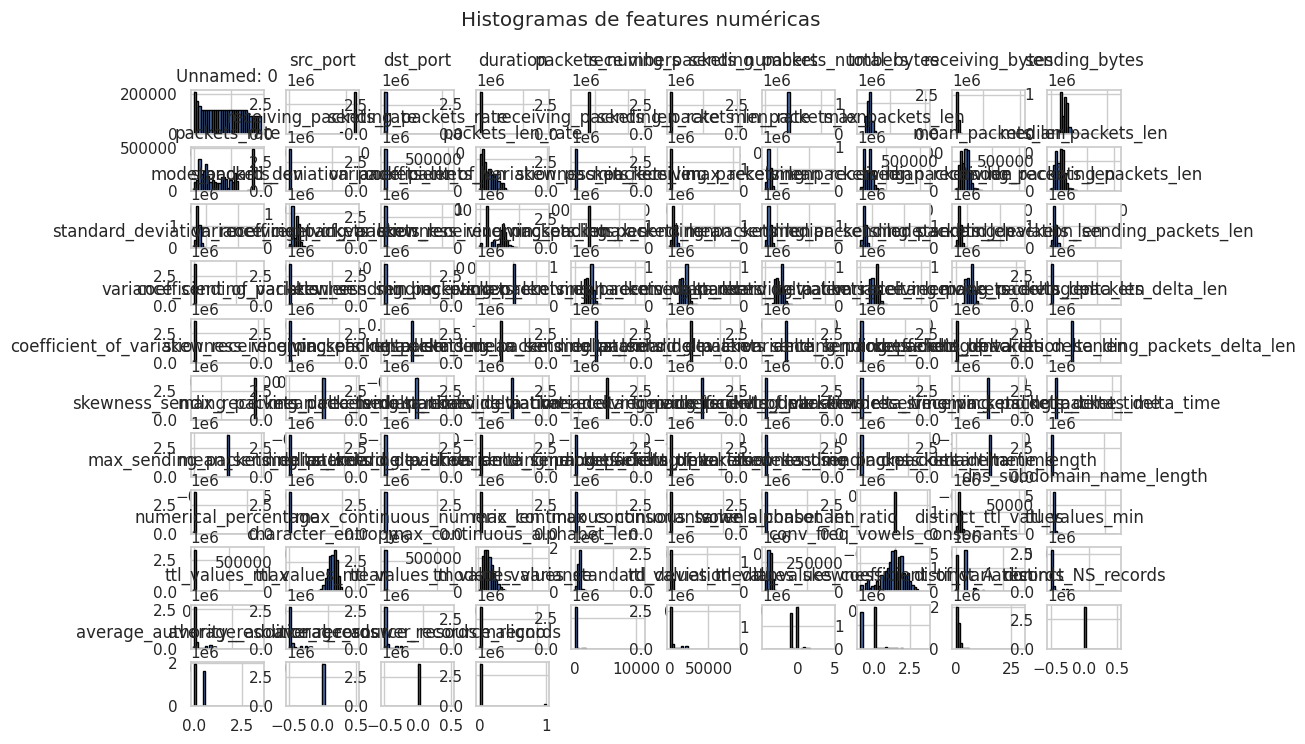

In [12]:
num_cols = df.select_dtypes(include=['number']).columns
print("\nFeatures numéricas:\n", df[num_cols].describe())

# Histogramas
df[num_cols].hist(figsize=(12, 8), bins=30, edgecolor='black')
plt.suptitle("Histogramas de features numéricas")
plt.tight_layout()
plt.show()

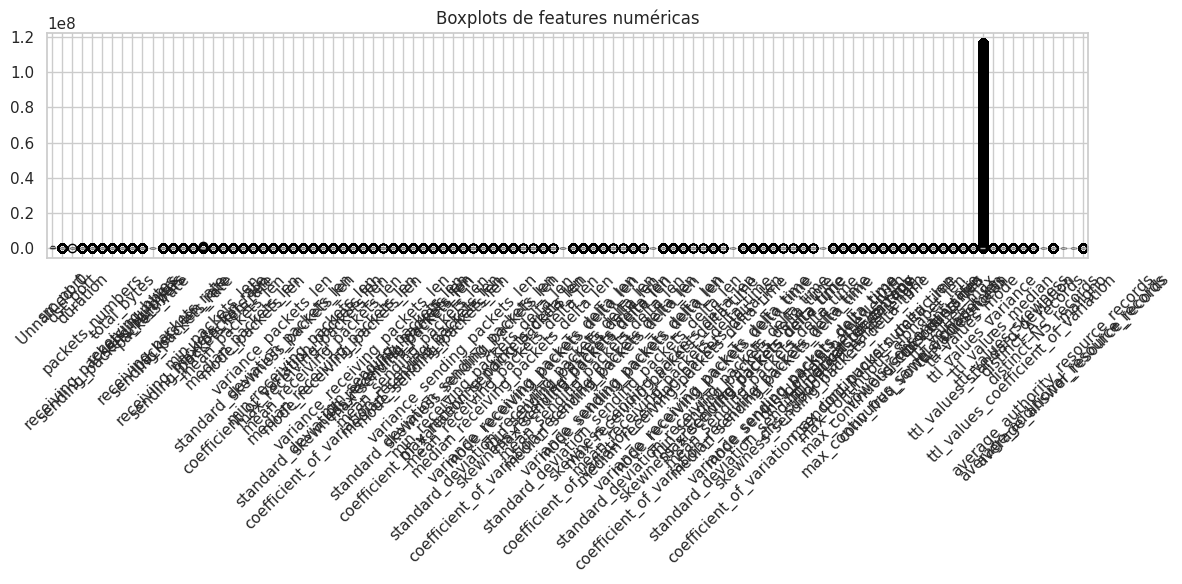

In [13]:
  # Boxplots
  plt.figure(figsize=(12, 6))
  df[num_cols].boxplot(rot=90)
  plt.title("Boxplots de features numéricas")
  plt.xticks(rotation=45)
  plt.tight_layout()
  plt.show()

# Matriz de correlação
O objetivo é identificar relações entre variáveis numéricas e descobrir variáveis altamente correlacionadas, para uma seleção de features consciente para uma modelagem futura.

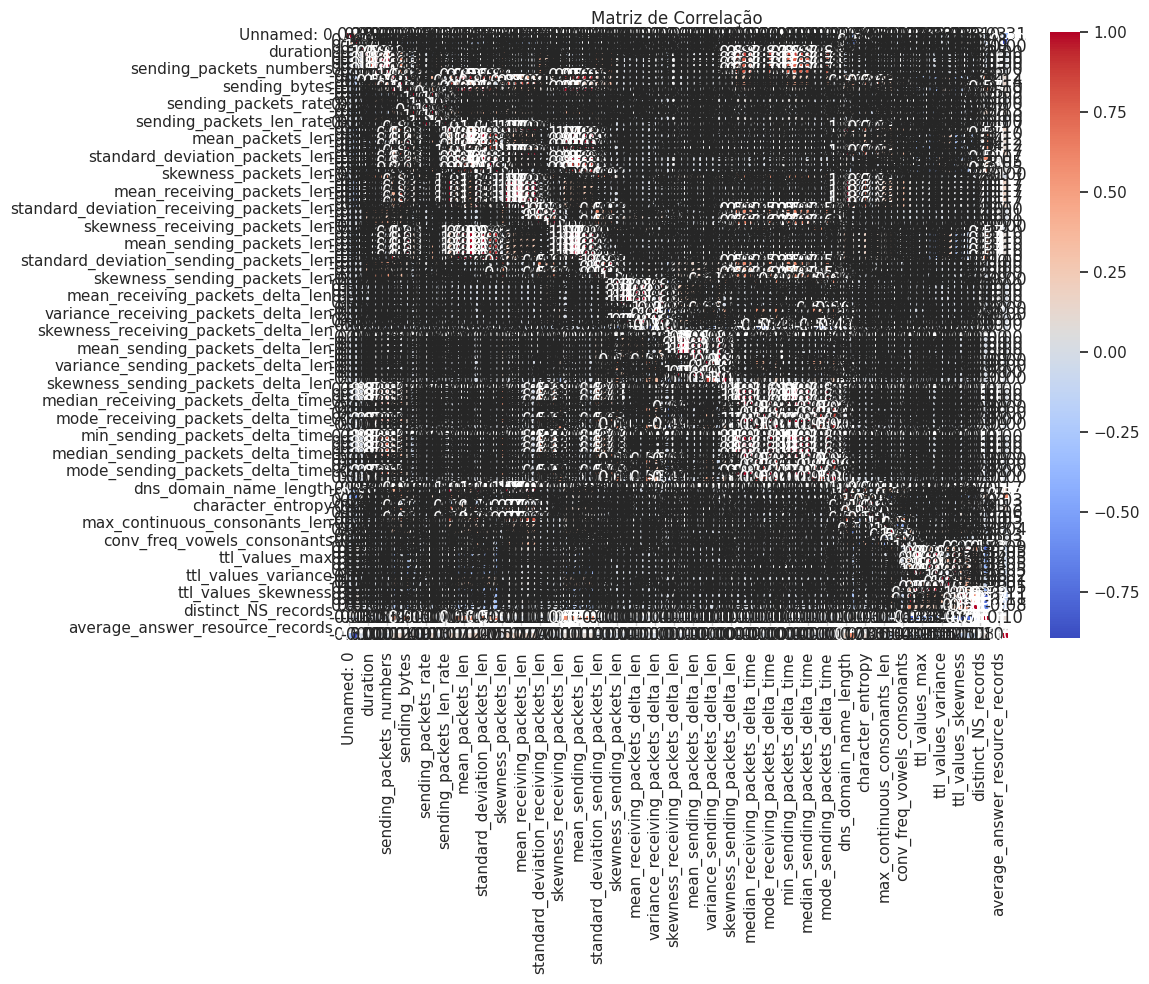

In [14]:
# Análise de correlação entre features numéricas:

num_cols = df.select_dtypes(include=['number']).columns
plt.figure(figsize=(12, 10))
sns.heatmap(df[num_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title("Matriz de Correlação")
plt.tight_layout()
plt.show()

# Análise de Cada Feature Numérica
O objetivo é estudar estatísticas detalhadas e distribuição de cada variável numérica.


Analisando a feature: Unnamed: 0
count    3.595920e+06
mean     4.157149e+05
std      2.608690e+05
min      0.000000e+00
25%      1.858900e+05
50%      4.106350e+05
75%      6.353800e+05
max      9.022400e+05
Name: Unnamed: 0, dtype: float64
Skewness: 0.09
Kurtosis: -1.18


/tmp/ipykernel_264527/3367561202.py:18: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df[feature])


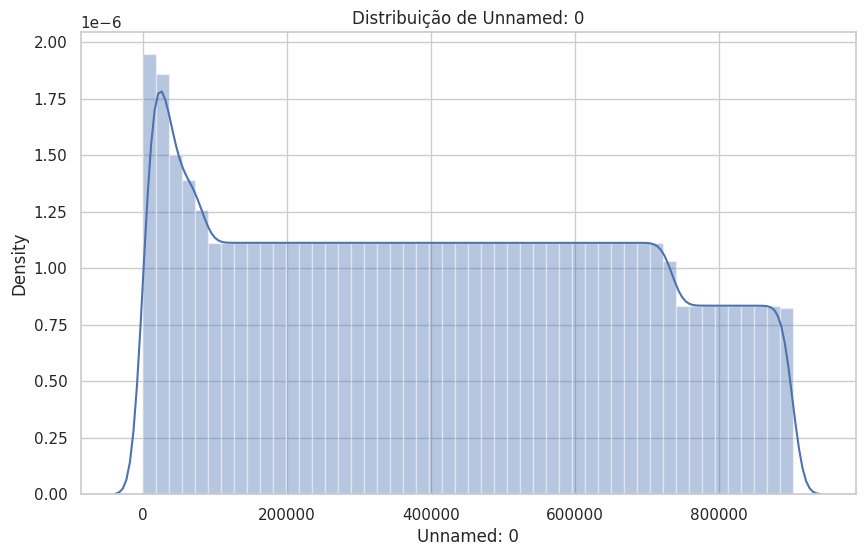

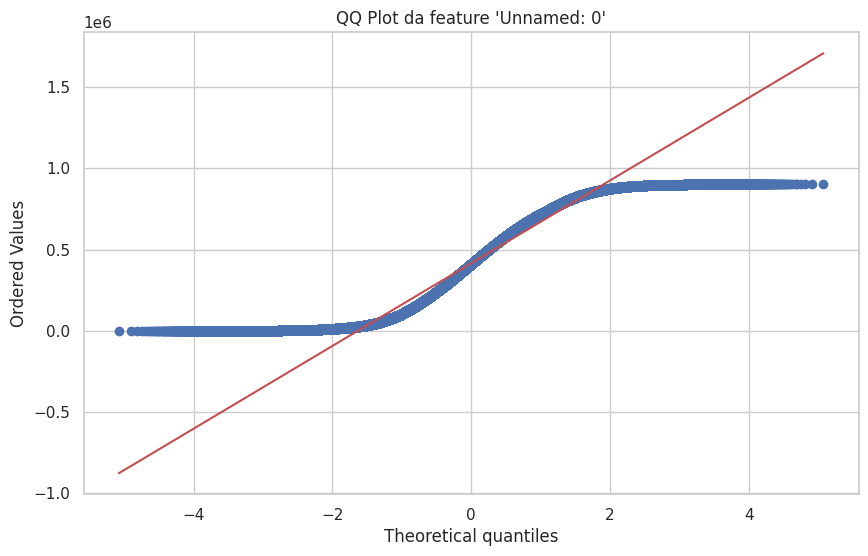

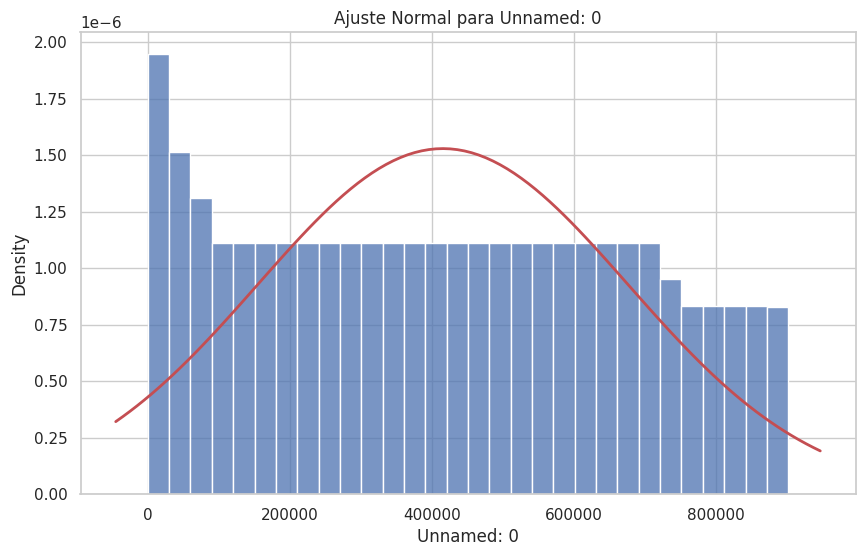


Analisando a feature: src_port
count    3.595920e+06
mean     5.766124e+04
std      2.180020e+03
min      5.300000e+01
25%      5.807500e+04
50%      5.807500e+04
75%      5.807500e+04
max      5.807500e+04
Name: src_port, dtype: float64
Skewness: -5.08
Kurtosis: 23.92


/tmp/ipykernel_264527/3367561202.py:18: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df[feature])


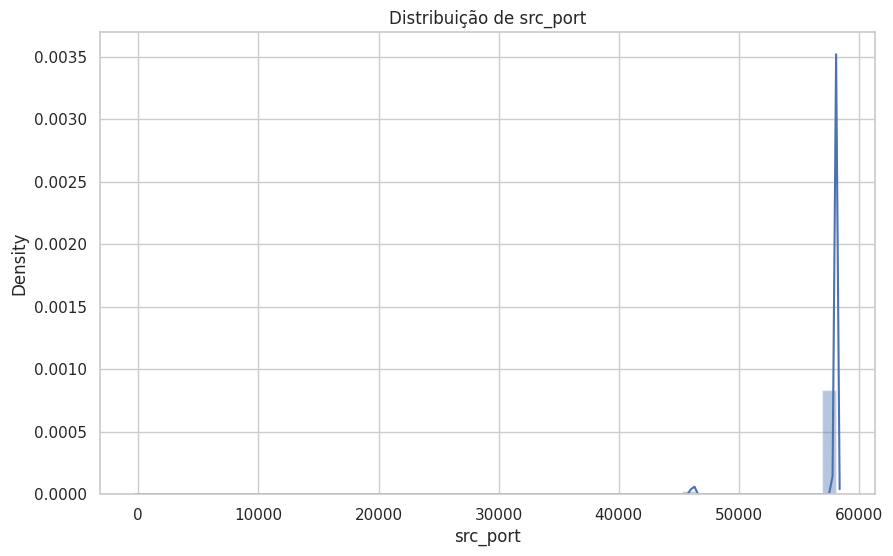

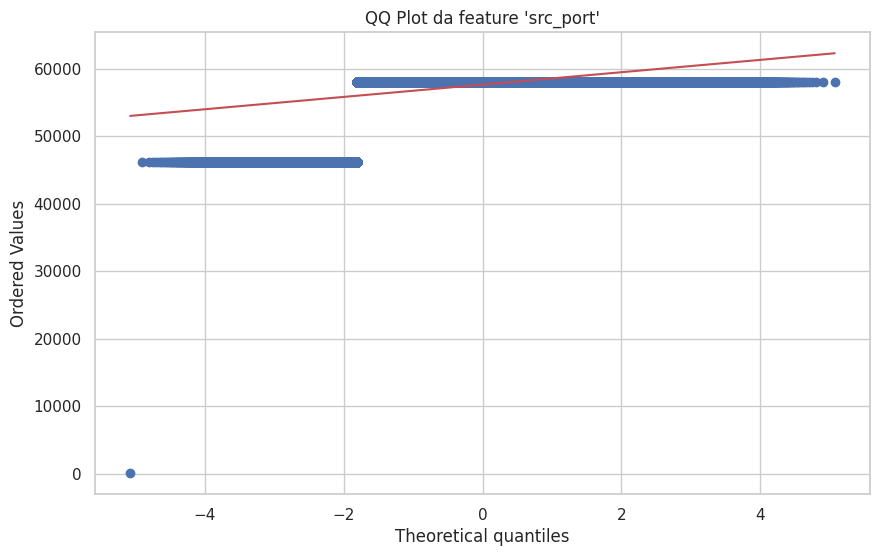

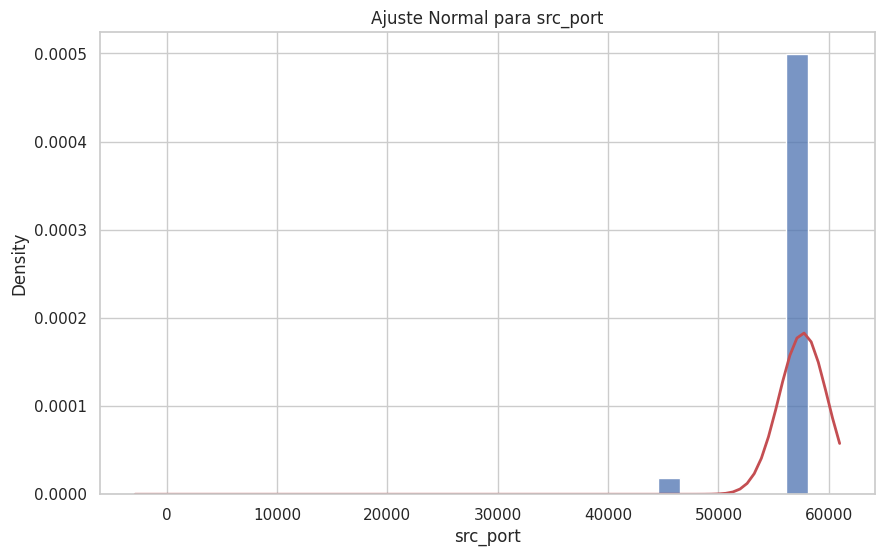


Analisando a feature: dst_port
count    3.595920e+06
mean     5.301614e+01
std      3.059762e+01
min      5.300000e+01
25%      5.300000e+01
50%      5.300000e+01
75%      5.300000e+01
max      5.807500e+04
Name: dst_port, dtype: float64
Skewness: 1896.29
Kurtosis: 3595920.00


/tmp/ipykernel_264527/3367561202.py:18: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df[feature])


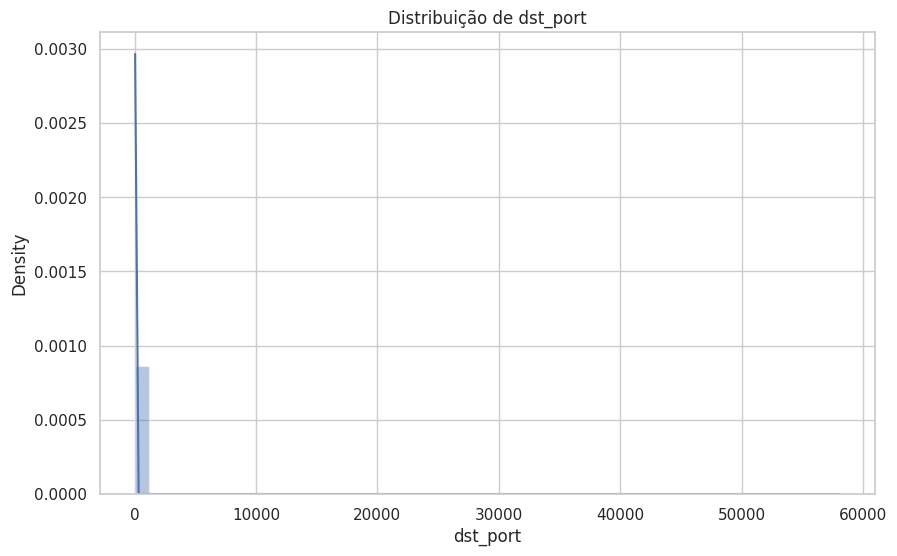

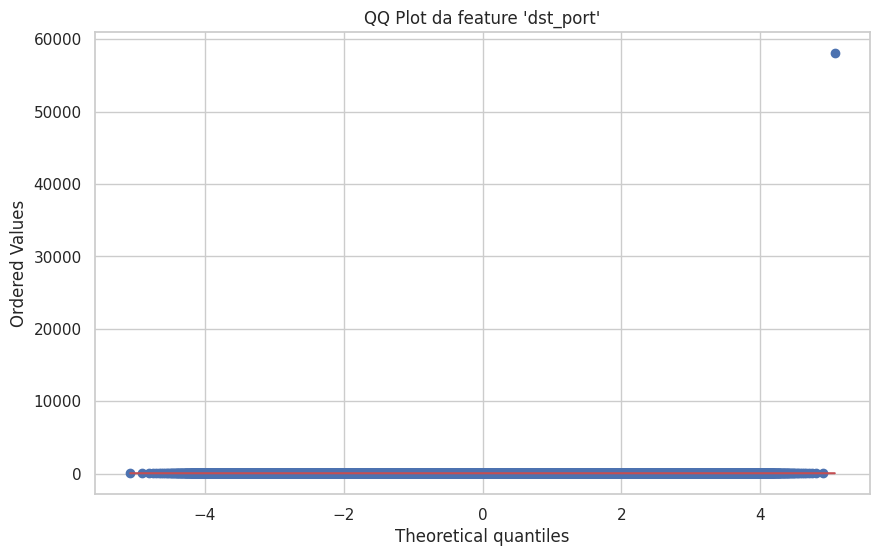

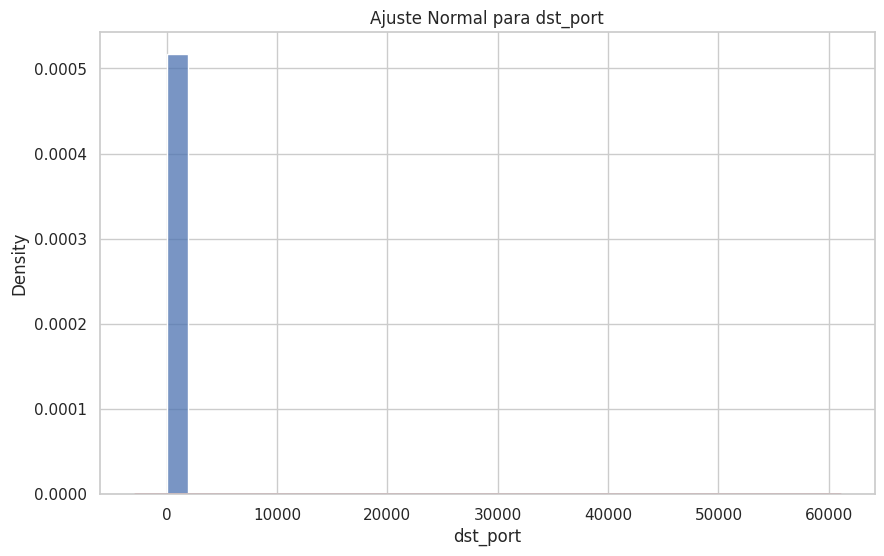


Analisando a feature: duration
count    3.595920e+06
mean     1.842521e-01
std      7.496046e-01
min      0.000000e+00
25%      3.850293e-02
50%      7.045817e-02
75%      1.487349e-01
max      3.845098e+01
Name: duration, dtype: float64
Skewness: 20.10
Kurtosis: 555.30


/tmp/ipykernel_264527/3367561202.py:18: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df[feature])


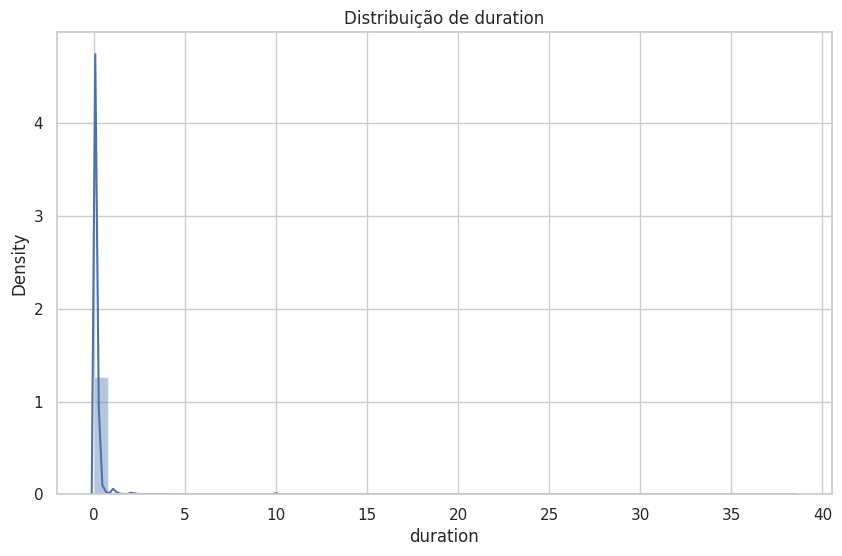

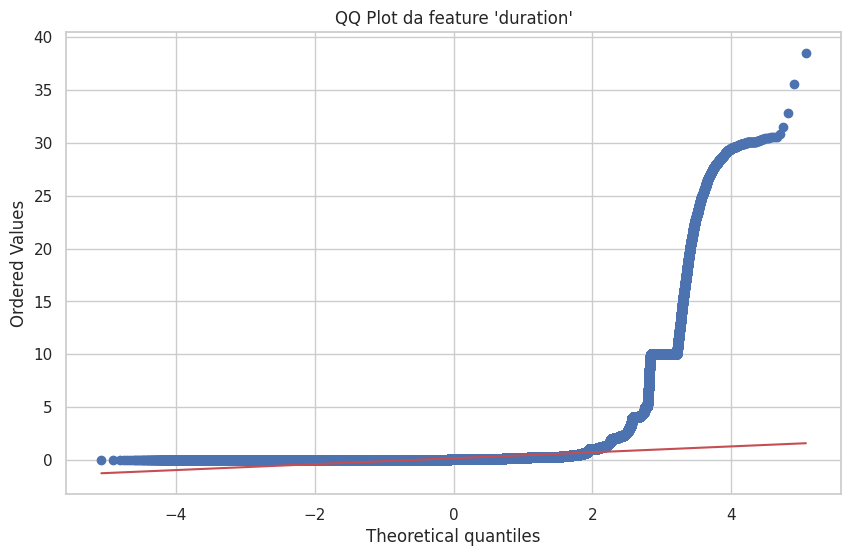

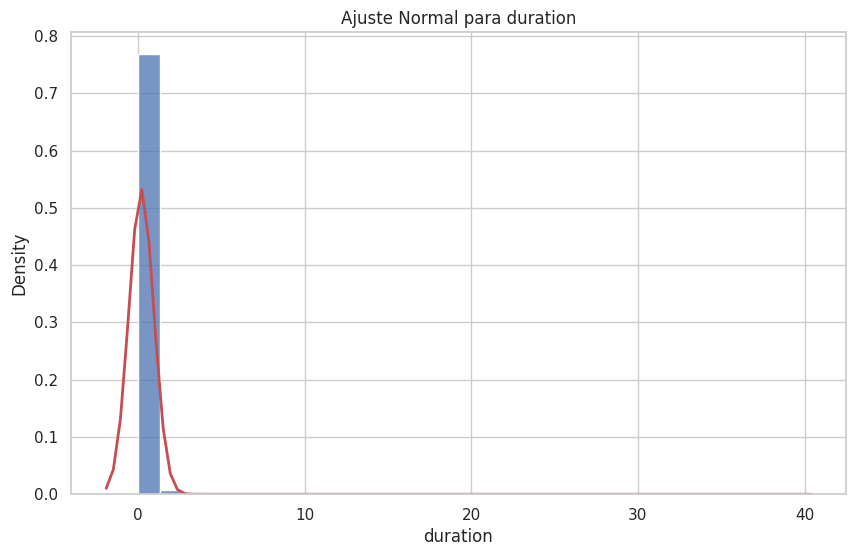


Analisando a feature: packets_numbers
count    3.595920e+06
mean     2.005771e+00
std      1.074844e-01
min      1.000000e+00
25%      2.000000e+00
50%      2.000000e+00
75%      2.000000e+00
max      6.000000e+00
Name: packets_numbers, dtype: float64
Skewness: 18.58
Kurtosis: 345.23


/tmp/ipykernel_264527/3367561202.py:18: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df[feature])


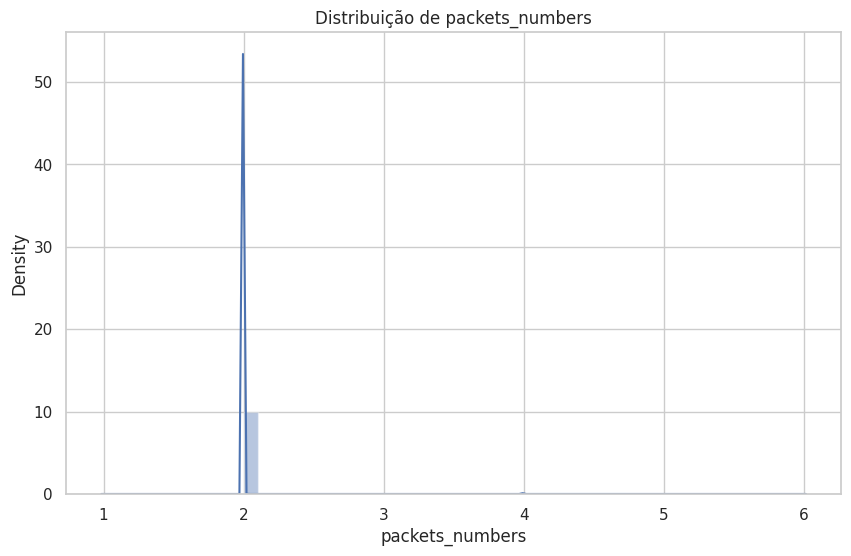

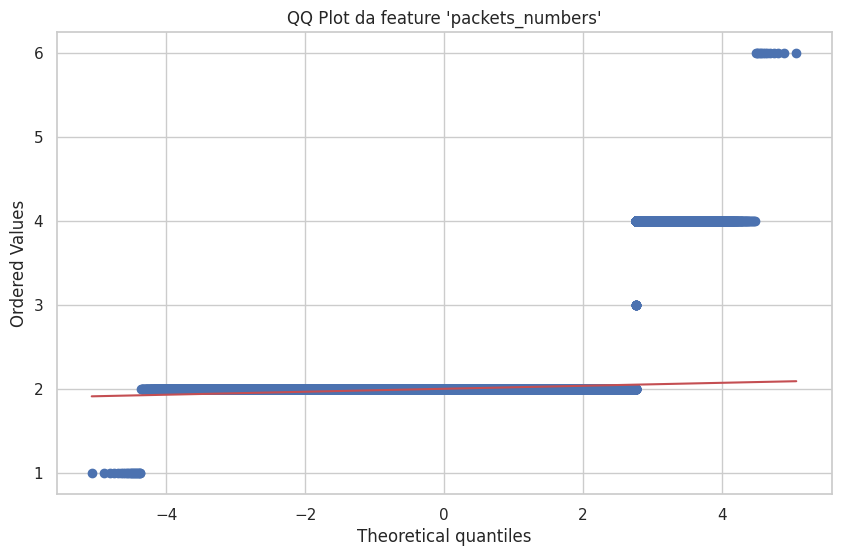

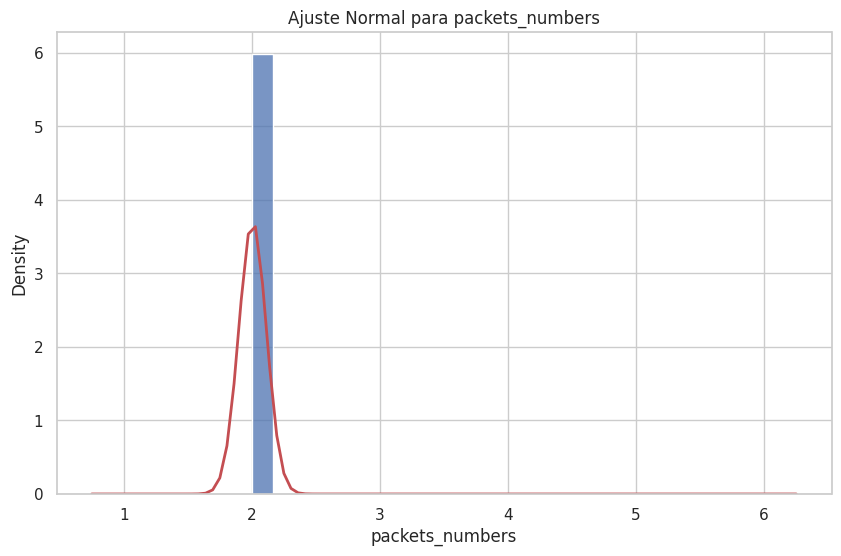


Analisando a feature: receiving_packets_numbers
count    3.595920e+06
mean     1.002890e+00
std      5.374518e-02
min      1.000000e+00
25%      1.000000e+00
50%      1.000000e+00
75%      1.000000e+00
max      3.000000e+00
Name: receiving_packets_numbers, dtype: float64
Skewness: 18.59
Kurtosis: 345.38


/tmp/ipykernel_264527/3367561202.py:18: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df[feature])


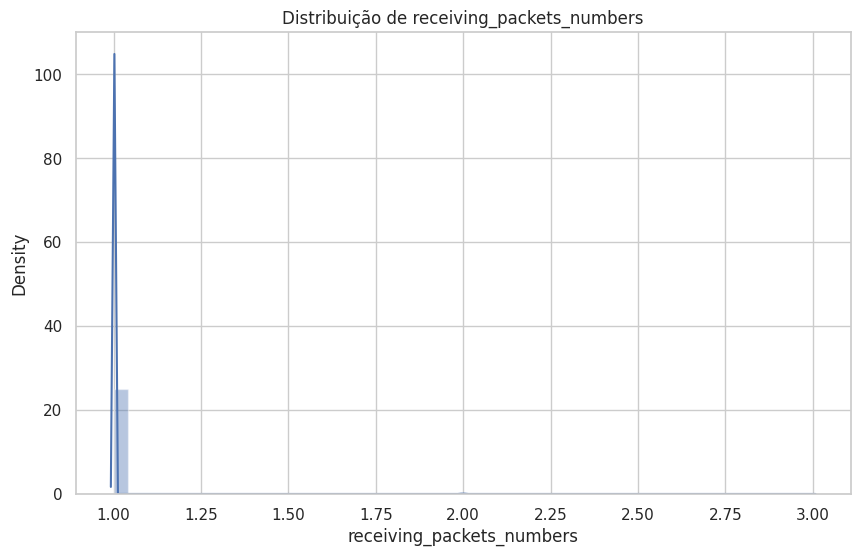

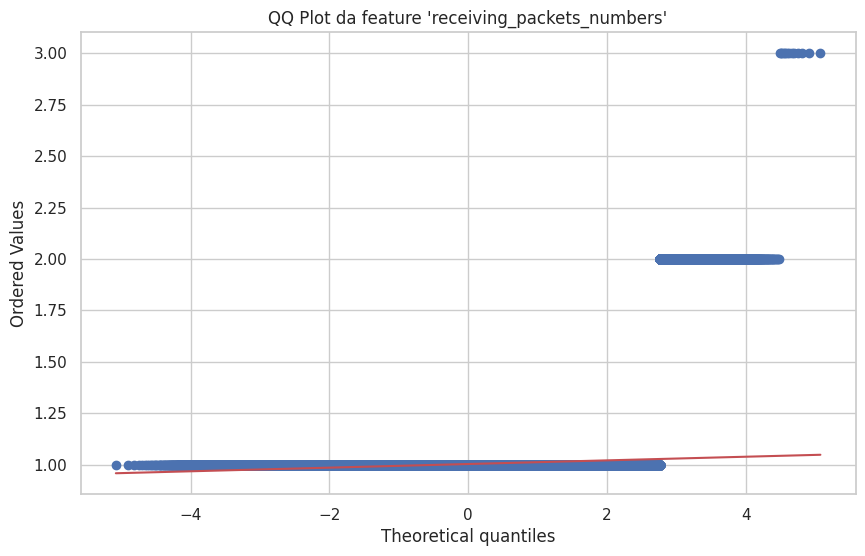

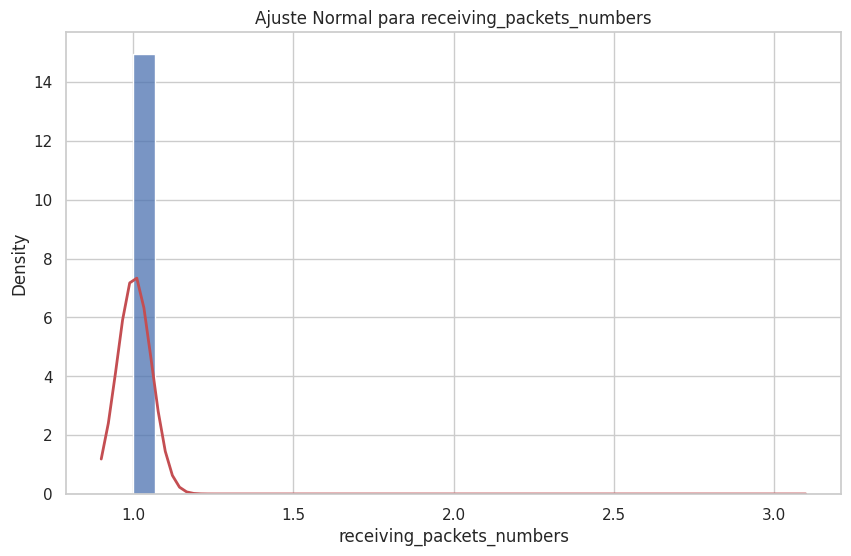


Analisando a feature: sending_packets_numbers
count    3.595920e+06
mean     1.002881e+00
std      5.377927e-02
min      0.000000e+00
25%      1.000000e+00
50%      1.000000e+00
75%      1.000000e+00
max      3.000000e+00
Name: sending_packets_numbers, dtype: float64
Skewness: 18.50
Kurtosis: 344.95


/tmp/ipykernel_264527/3367561202.py:18: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df[feature])


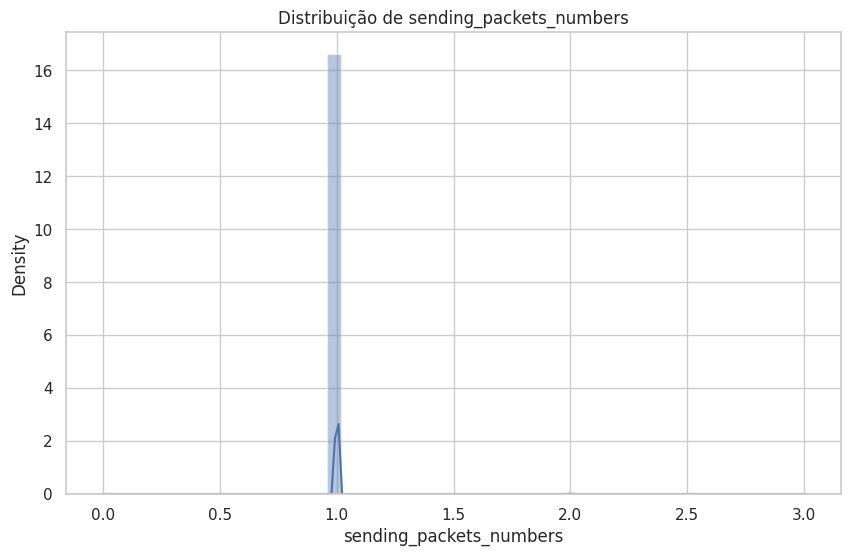

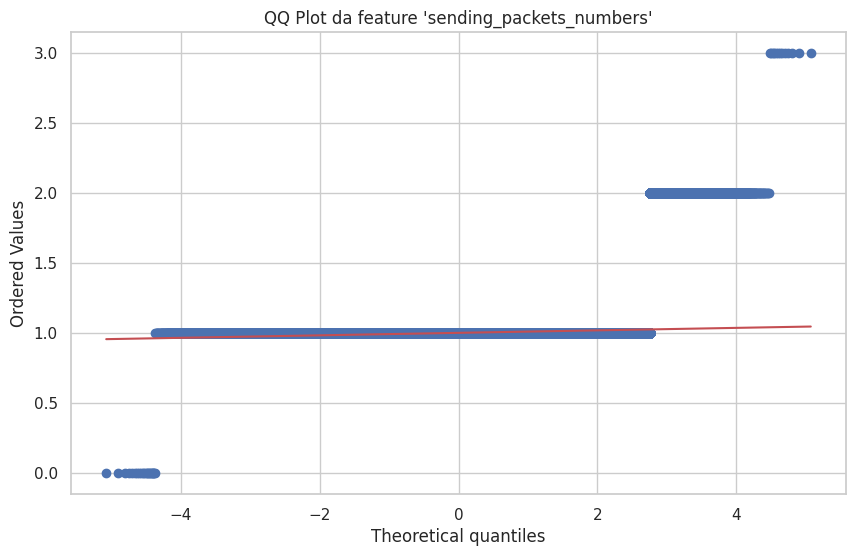

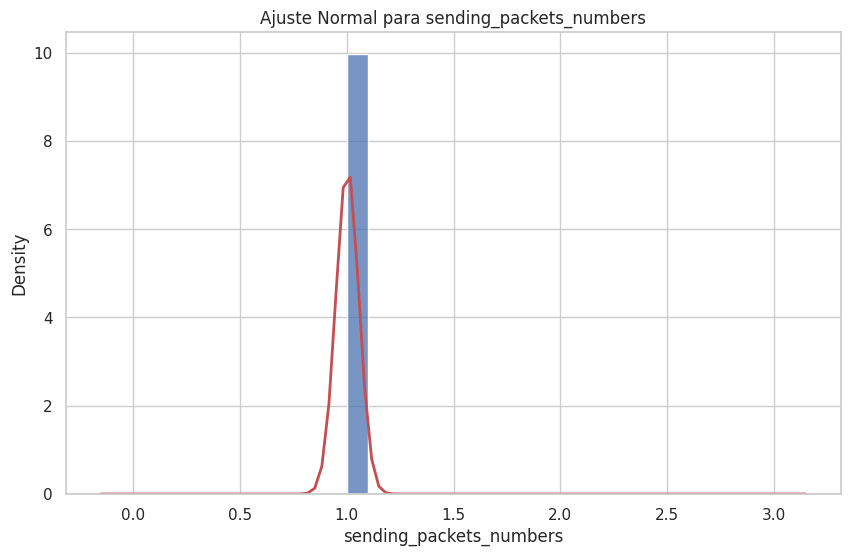


Analisando a feature: total_bytes
count    3.595920e+06
mean     1.990830e+02
std      3.572011e+01
min      6.800000e+01
25%      1.700000e+02
50%      2.000000e+02
75%      2.180000e+02
max      1.028000e+03
Name: total_bytes, dtype: float64
Skewness: 1.51
Kurtosis: 6.42


/tmp/ipykernel_264527/3367561202.py:18: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df[feature])


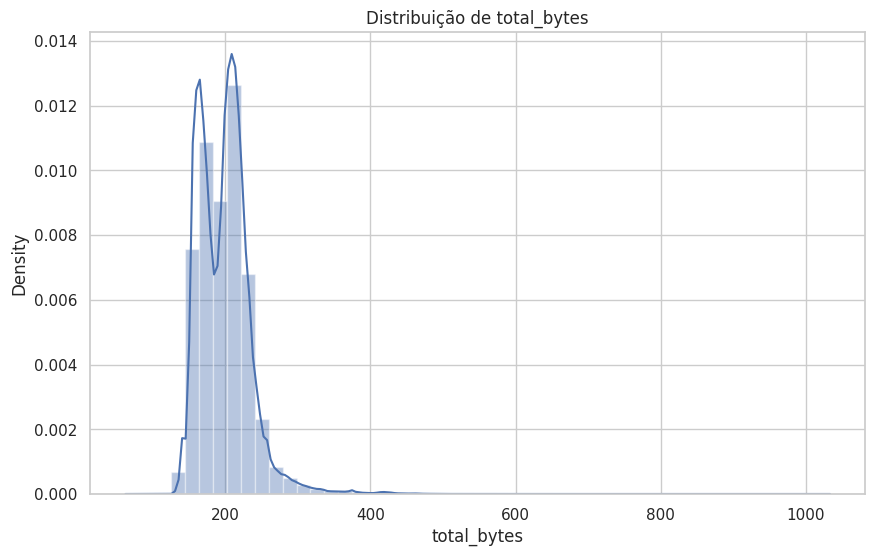

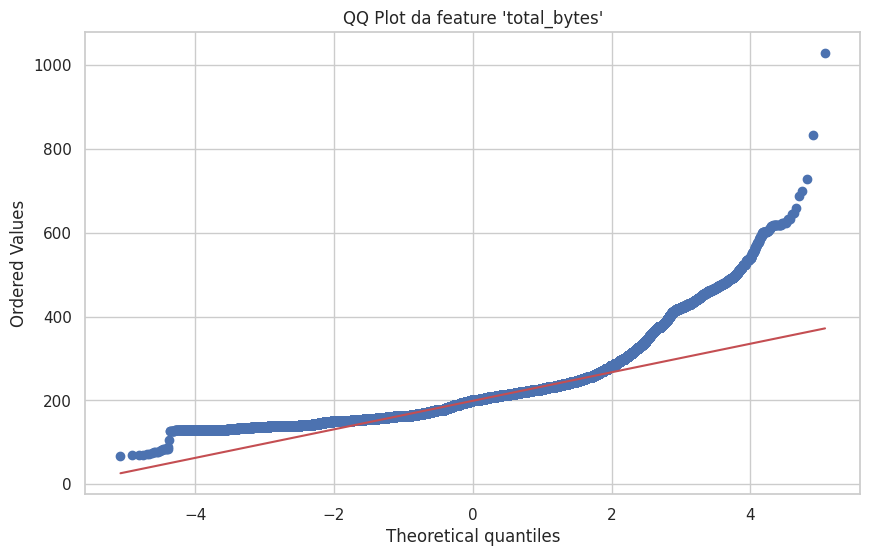

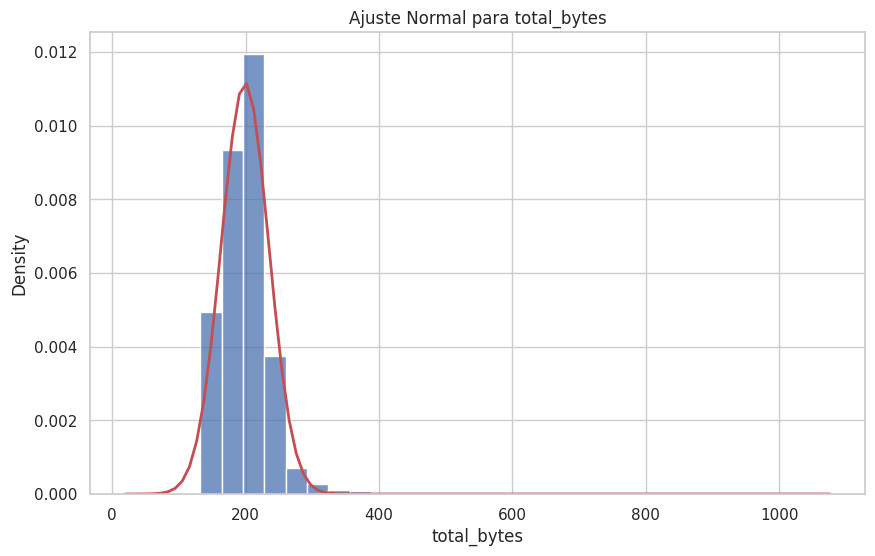


Analisando a feature: receiving_bytes
count    3.595920e+06
mean     7.571718e+01
std      6.884119e+00
min      6.300000e+01
25%      7.200000e+01
50%      7.500000e+01
75%      7.900000e+01
max      5.140000e+02
Name: receiving_bytes, dtype: float64
Skewness: 4.81
Kurtosis: 56.11


/tmp/ipykernel_264527/3367561202.py:18: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df[feature])


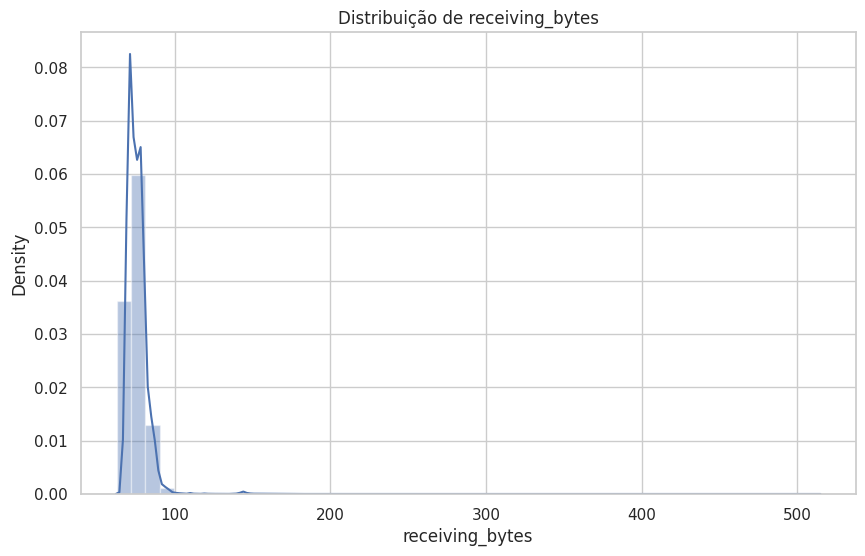

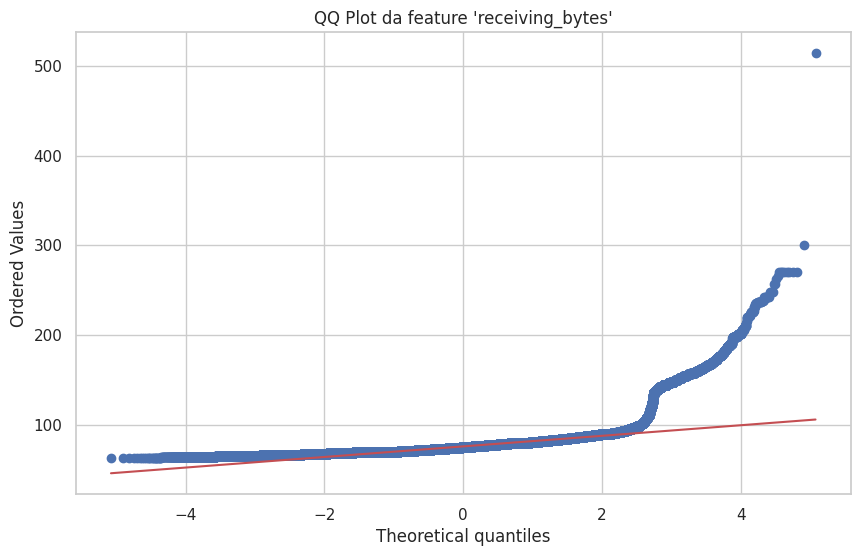

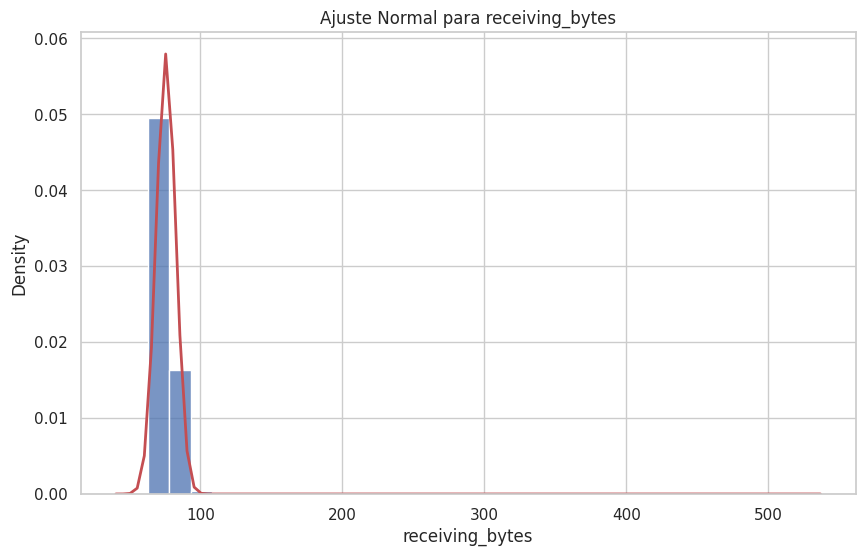


Analisando a feature: sending_bytes
count    3.595920e+06
mean     1.233658e+02
std      3.325523e+01
min      0.000000e+00
25%      9.400000e+01
50%      1.270000e+02
75%      1.420000e+02
max      5.950000e+02
Name: sending_bytes, dtype: float64
Skewness: 1.48
Kurtosis: 6.27


/tmp/ipykernel_264527/3367561202.py:18: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df[feature])


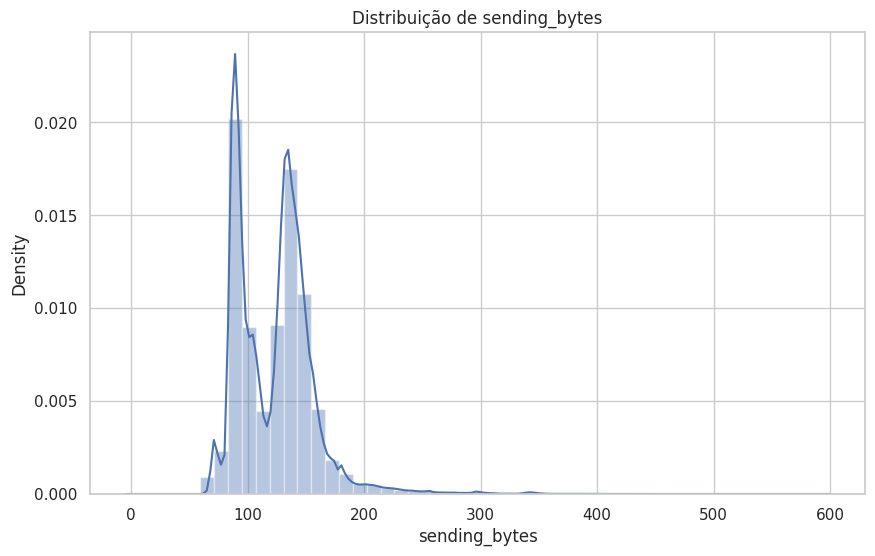

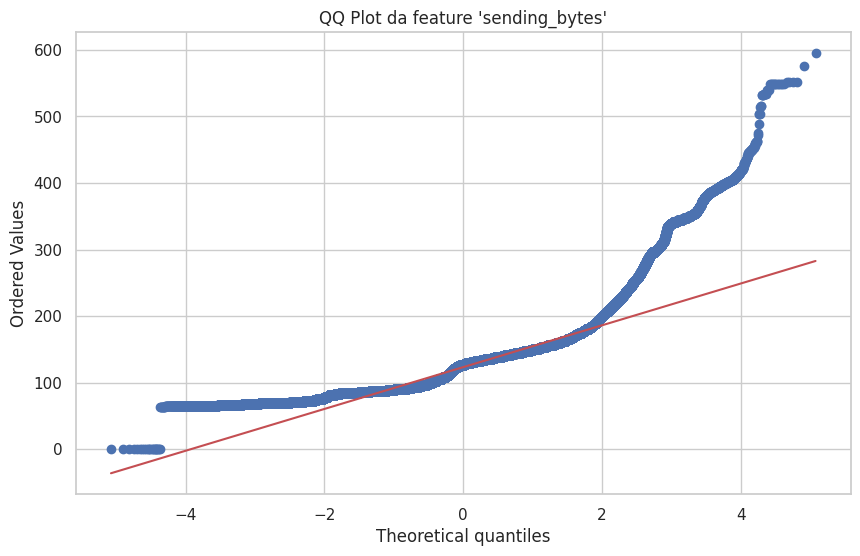

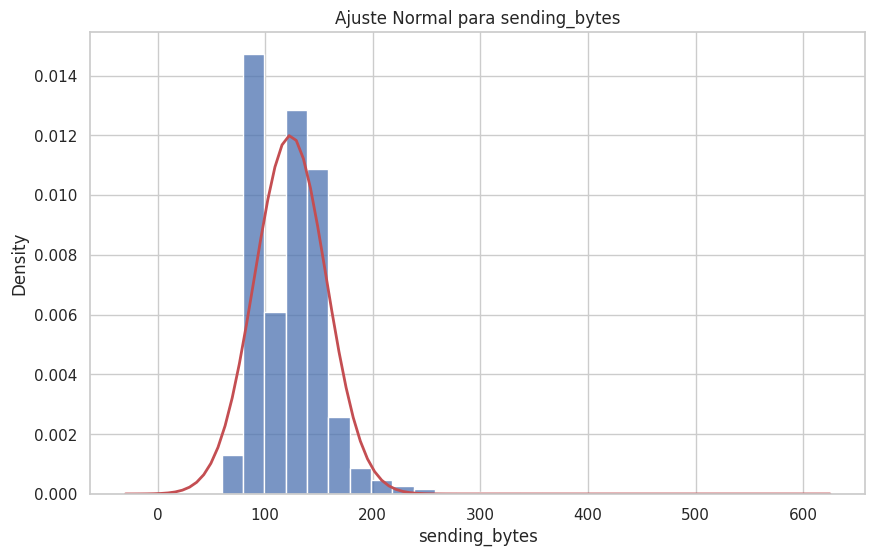


Analisando a feature: packets_rate
count    3.595920e+06
mean     3.369670e+01
std      2.414468e+01
min      0.000000e+00
25%      1.344700e+01
50%      2.838535e+01
75%      5.194281e+01
max      8.901513e+01
Name: packets_rate, dtype: float64
Skewness: 0.59
Kurtosis: -0.83


/tmp/ipykernel_264527/3367561202.py:18: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df[feature])


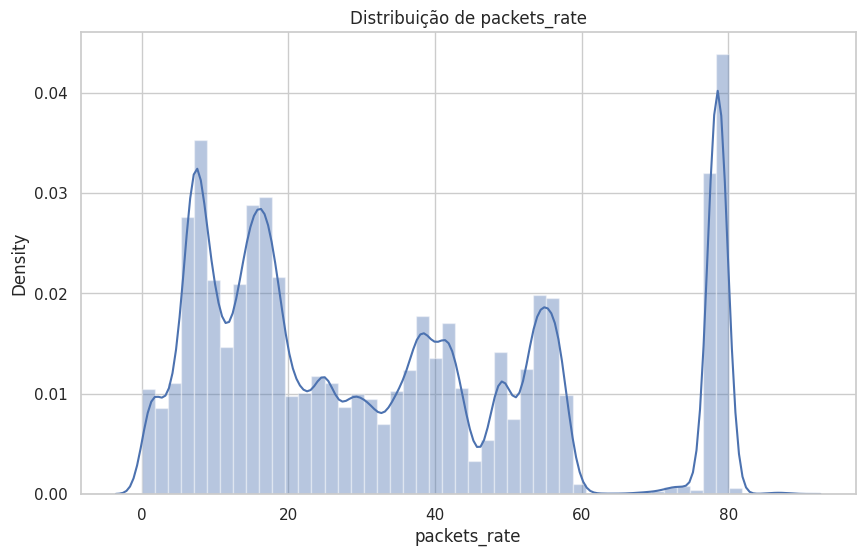

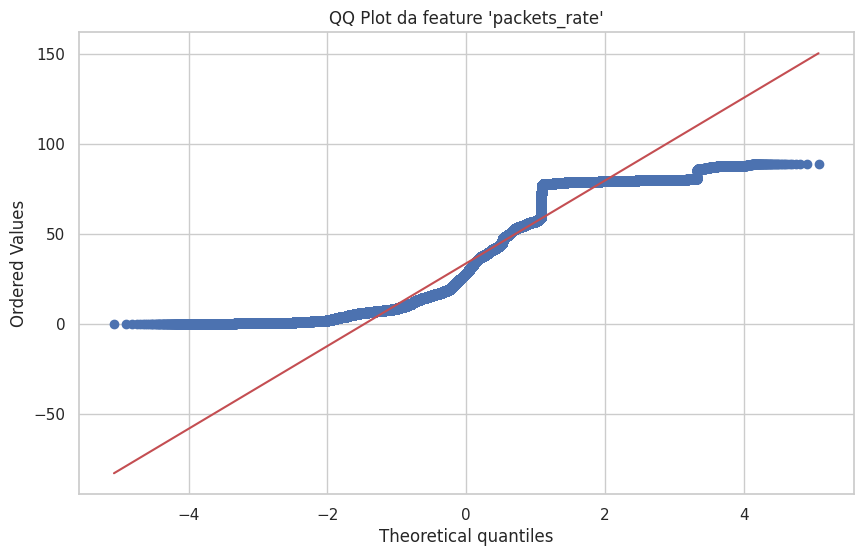

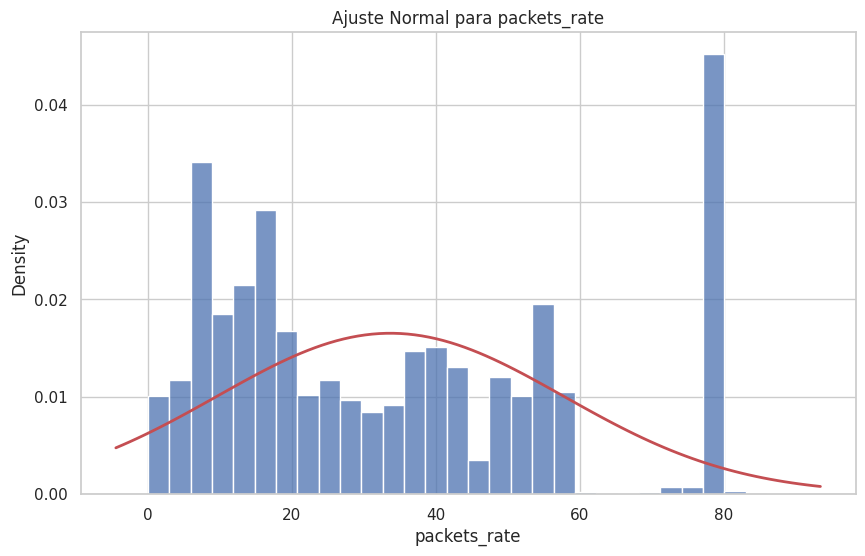


Analisando a feature: receiving_packets_rate
count    3.595920e+06
mean     1.536390e-03
std      1.352889e-01
min      0.000000e+00
25%      0.000000e+00
50%      0.000000e+00
75%      0.000000e+00
max      7.851782e+01
Name: receiving_packets_rate, dtype: float64
Skewness: 391.45
Kurtosis: 184136.14


/tmp/ipykernel_264527/3367561202.py:18: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df[feature])


In [ ]:
# análise de cada feature específica:

num_features = df.select_dtypes(include=['int64', 'float64']).columns
for feature in num_features:
        print(f"\nAnalisando a feature: {feature}")
        print(df[feature].describe())

        # Skewness (assimetria) e Kurtosis (curtose)

        # skewness: tendência de inclinação na distribuição de dados
        print(f"Skewness: {df[feature].skew():.2f}")

        # kurtosis (grau de pico de uma distribuição):
        print(f"Kurtosis: {df[feature].kurt():.2f}")

        # Distribuição dos dados
        plt.figure(figsize= (10,6))
        sns.distplot(df[feature])
        plt.title(f"Distribuição de {feature}")
        plt.show()

        # QQ Plot
        plt.figure(figsize=(10, 6))
        st.probplot(df[feature], dist="norm", plot=plt)
        plt.title(f"QQ Plot da feature '{feature}'")
        plt.show()

        # Distribuição normal ajustada
        plt.figure(figsize=(10, 6))
        sns.histplot(df[feature], kde=False, bins=30, stat="density")
        x_min, x_max = plt.xlim()
        x = np.linspace(x_min, x_max, 100)
        p = st.norm.pdf(x, df[feature].mean(), df[feature].std())
        plt.plot(x, p, 'r', linewidth=2)
        plt.title(f'Ajuste Normal para {feature}')
        plt.show()


# Análise de Features Categóricas
Assim como as features numéricas, é interessante entender as features categóricas, suas estruturas e distribuições.

In [ ]:
# Análise de features categóricas
cat_cols = df.select_dtypes(exclude=['number']).columns
for col in cat_cols:
    print(f"\nValores para {col}:\n", df[col].value_counts())
    plt.figure(figsize=(8, 5))
    sns.countplot(x=df[col], order=df[col].value_counts().index)
    plt.title(f"Distribuição de {col}")
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

# Identificação de Outliers
Busca de possíveis valores anômalos que podem afetar a modelagem.

In [ ]:
# verificação da existência de outliers por coluna, usando o método IQR
num_cols = df.select_dtypes(include=['number']).columns
outliers = {}
for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    outliers[col] = df[(df[col] < (Q1 - 1.5 * IQR)) | (df[col] > (Q3 + 1.5 * IQR))].shape[0]
print("\nOutliers detectados por coluna:\n", outliers)

# Relações Entre Features Numéricas
O objetivo é identificar padrões de relacionamento (linear, exponencial, etc.) a partir da visualização gráfica que mostra o comportamento entre as variáveis consideradas.

In [ ]:
# Pairplot entre variáveis numéricas
num_var = df.select_dtypes(include=['int64', 'float64']).columns
sns.pairplot(df[num_var])
plt.show()


# Relações Entre Features numéricas e categóricas

Verificação de relações entre as features, com gráficos boxplots e violin plots.


In [ ]:
# Scatter plots com regressão para algumas variáveis importantes
sns.lmplot(x=num_var[0], y=num_var[1], data=df)
plt.show()



In [ ]:
# Boxplots de variáveis numéricas em relação a categorias
for col in cat_cols:
    plt.figure(figsize=(15,5))
    sns.boxplot(x=col, y=num_var[0], data=df)
    plt.title(f'Distribuição de {num_var[0]} por {col}')
    plt.show()



In [ ]:
# análise das relações entre features numéricas e categóricas usando violin plot
for cat_col in df.select_dtypes(include=['object', 'category']).columns:
    for num_col in df.select_dtypes(include=['int64', 'float64']).columns:
        plt.figure(figsize=(12, 5))
        sns.violinplot(x=df[cat_col], y=df[num_col])
        plt.title(f"Distribuição de {num_col} por {cat_col}")
        plt.xticks(rotation=45)
        plt.show()